# Prophet Plots for Final Presentation

Python reproduction of Charlie's `prophet.qmd` plots. The notebook fits daily, weekly, and monthly Prophet models from shipped-order counts and saves presentation-ready PNGs in `joel/final_presentation/prophet-plots`.

In [1]:
from pathlib import Path
import contextlib
import io
import logging
import warnings

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import Image, display
from prophet import Prophet


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'joel').exists() and (candidate / 'charlie').exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
PRESENTATION_DIR = PROJECT_ROOT / 'joel' / 'final_presentation'
PLOT_DIR = PRESENTATION_DIR / 'prophet-plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

COUNT_PATH_CANDIDATES = [
    PROJECT_ROOT / 'joel' / 'kaggle_sumissions' / 'submission4' / 'order_shipped_ts.csv',
    PROJECT_ROOT / 'joel' / 'kaggle_sumissions' / 'submission3' / 'order_shipped_ts.csv',
    PROJECT_ROOT / 'joel' / 'final_presentation' / 'order_shipped_ts.csv',
]
COUNT_PATH = next(path for path in COUNT_PATH_CANDIDATES if path.exists())

FORECAST_END = pd.Timestamp('2024-12-01')
START_CUTOFF_DAYS = 71

print('Project root:', PROJECT_ROOT)
print('Using shipped-order counts:', COUNT_PATH)
print('Saving plots to:', PLOT_DIR)

Project root: /Users/joelyoon/Documents/git_repo/m148-project
Using shipped-order counts: /Users/joelyoon/Documents/git_repo/m148-project/joel/kaggle_sumissions/submission4/order_shipped_ts.csv
Saving plots to: /Users/joelyoon/Documents/git_repo/m148-project/joel/final_presentation/prophet-plots


## Prepare Prophet Series

In [2]:
orders = pd.read_csv(COUNT_PATH, parse_dates=['date'])
orders = orders.rename(columns={'date': 'ds', 'n_order_shipped': 'y'})[['ds', 'y']]
orders = orders.sort_values('ds').reset_index(drop=True)

# Charlie's notebook drops the early history window because ongoing journeys at the
# beginning of the data would not have had enough time to ship. He used the 80th
# percentile of successful journey length, which was 71 days.
start_cutoff = orders['ds'].min() + pd.Timedelta(days=START_CUTOFF_DAYS)
prophet_train_data = orders[orders['ds'] > start_cutoff].copy()

# Warehouse/order fulfillment is mostly weekday-based, so Charlie drops weekends
# for the daily model.
daily_train_data = prophet_train_data[prophet_train_data['ds'].dt.dayofweek < 5].copy()

weekly_train_data = prophet_train_data.copy()
weekly_train_data['ds'] = weekly_train_data['ds'].dt.to_period('W').apply(lambda period: period.start_time)
weekly_train_data = weekly_train_data.groupby('ds', as_index=False)['y'].sum().sort_values('ds')

monthly_train_data = prophet_train_data.copy()
monthly_train_data['ds'] = monthly_train_data['ds'].dt.to_period('M').dt.to_timestamp()
monthly_train_data = monthly_train_data.groupby('ds', as_index=False)['y'].sum().sort_values('ds')
monthly_train_data = monthly_train_data[
    (monthly_train_data['ds'] > pd.Timestamp('2021-01-01'))
    & (monthly_train_data['ds'] < pd.Timestamp('2023-01-01'))
].copy()

print('Start cutoff:', start_cutoff.date())
print('Daily weekday rows:', len(daily_train_data))
print('Weekly rows:', len(weekly_train_data))
print('Monthly rows:', len(monthly_train_data))
display(daily_train_data.head())

Start cutoff: 2021-04-13
Daily weekday rows: 636
Weekly rows: 128
Monthly rows: 21


,ds,y
72,2021-04-14,740
73,2021-04-15,1032
74,2021-04-16,670
77,2021-04-19,874
78,2021-04-20,821


## Fit Prophet Models

In [3]:
def fit_prophet(train_data: pd.DataFrame, *, weekly: bool, holidays: bool) -> Prophet:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=weekly,
        daily_seasonality=False,
    )
    if holidays:
        model.add_country_holidays(country_name='US')
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return model.fit(train_data)


def future_dates(train_data: pd.DataFrame, freq: str) -> pd.DataFrame:
    start = train_data['ds'].min()
    end = max(FORECAST_END, train_data['ds'].max())
    return pd.DataFrame({'ds': pd.date_range(start, end, freq=freq)})


daily_model = fit_prophet(daily_train_data, weekly=True, holidays=True)
daily_forecast = daily_model.predict(future_dates(daily_train_data, 'D'))
if 'holidays' not in daily_forecast.columns:
    daily_forecast['holidays'] = 0.0

weekly_model = fit_prophet(weekly_train_data, weekly=False, holidays=False)
weekly_forecast = weekly_model.predict(future_dates(weekly_train_data, 'W'))

monthly_model = fit_prophet(monthly_train_data, weekly=False, holidays=False)
monthly_forecast = monthly_model.predict(future_dates(monthly_train_data, 'MS'))

print('Daily forecast rows:', len(daily_forecast))
print('Weekly forecast rows:', len(weekly_forecast))
print('Monthly forecast rows:', len(monthly_forecast))

Daily forecast rows: 1328
Weekly forecast rows: 190
Monthly forecast rows: 45


## Save Forecast and Component Plots

In [4]:
def save_prophet_forecast_plot(model: Prophet, forecast: pd.DataFrame, path: Path, title: str) -> None:
    fig = model.plot(forecast)
    fig.set_size_inches(8, 4)
    ax = fig.axes[0]
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Orders Shipped')
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.close(fig)


def save_prophet_components_plot(model: Prophet, forecast: pd.DataFrame, path: Path) -> None:
    fig = model.plot_components(forecast)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.close(fig)


save_prophet_forecast_plot(
    daily_model,
    daily_forecast,
    PLOT_DIR / 'daily_forecast.png',
    'Daily Orders Forecast through 2024',
)
save_prophet_components_plot(daily_model, daily_forecast, PLOT_DIR / 'daily_components.png')
save_prophet_components_plot(daily_model, daily_forecast, PLOT_DIR / 'prophet_all_components.png')

save_prophet_forecast_plot(
    weekly_model,
    weekly_forecast,
    PLOT_DIR / 'weekly_forecast.png',
    'Weekly Orders Forecast through 2024',
)

save_prophet_forecast_plot(
    monthly_model,
    monthly_forecast,
    PLOT_DIR / 'monthly_forecast.png',
    'Monthly Orders Forecast through 2024',
)

print('Saved Prophet forecast/component plots.')

Saved Prophet forecast/component plots.


## Save Custom Presentation Plots

In [5]:
# Reproduce Charlie's monthly-order view with observed monthly totals and the
# Prophet monthly forecast on the same axis.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(monthly_train_data['ds'], monthly_train_data['y'], width=24, alpha=0.45, label='Observed monthly orders')
ax.plot(monthly_forecast['ds'], monthly_forecast['yhat'], color='tab:blue', linewidth=2.0, label='Prophet forecast')
ax.fill_between(
    monthly_forecast['ds'],
    monthly_forecast['yhat_lower'],
    monthly_forecast['yhat_upper'],
    color='tab:blue',
    alpha=0.15,
    label='Uncertainty interval',
)
ax.set_title('Monthly Order Volume Forecast')
ax.set_xlabel('Month')
ax.set_ylabel('Orders Shipped')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'monthly_order_forecast.png', dpi=300, bbox_inches='tight')
plt.close(fig)


def align_to_2023(date_value: pd.Timestamp) -> pd.Timestamp:
    try:
        return date_value.replace(year=2023)
    except ValueError:
        return date_value.replace(year=2023, day=28)


holiday_data = daily_forecast[['ds', 'holidays']].copy()
holiday_data['Year'] = holiday_data['ds'].dt.year.astype(str)
holiday_data['dummy_date'] = holiday_data['ds'].apply(align_to_2023)

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='darkgray', linestyle='--', linewidth=1)
for year, group in holiday_data.groupby('Year'):
    ax.plot(group['dummy_date'], group['holidays'], linewidth=1.0, alpha=0.75, label=year)
    nonzero = group[group['holidays'] != 0]
    ax.scatter(nonzero['dummy_date'], nonzero['holidays'], s=10)
ax.set_title('Year-Over-Year Holiday Effect on Order Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Holiday Effect')
ax.legend(title='Year', ncol=2, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.tight_layout()
fig.savefig(PLOT_DIR / 'holiday_seasonality_yoy.png', dpi=300, bbox_inches='tight')
plt.close(fig)

print('Saved custom monthly and holiday plots.')

Saved custom monthly and holiday plots.


## Display Plots

### Daily Forecast

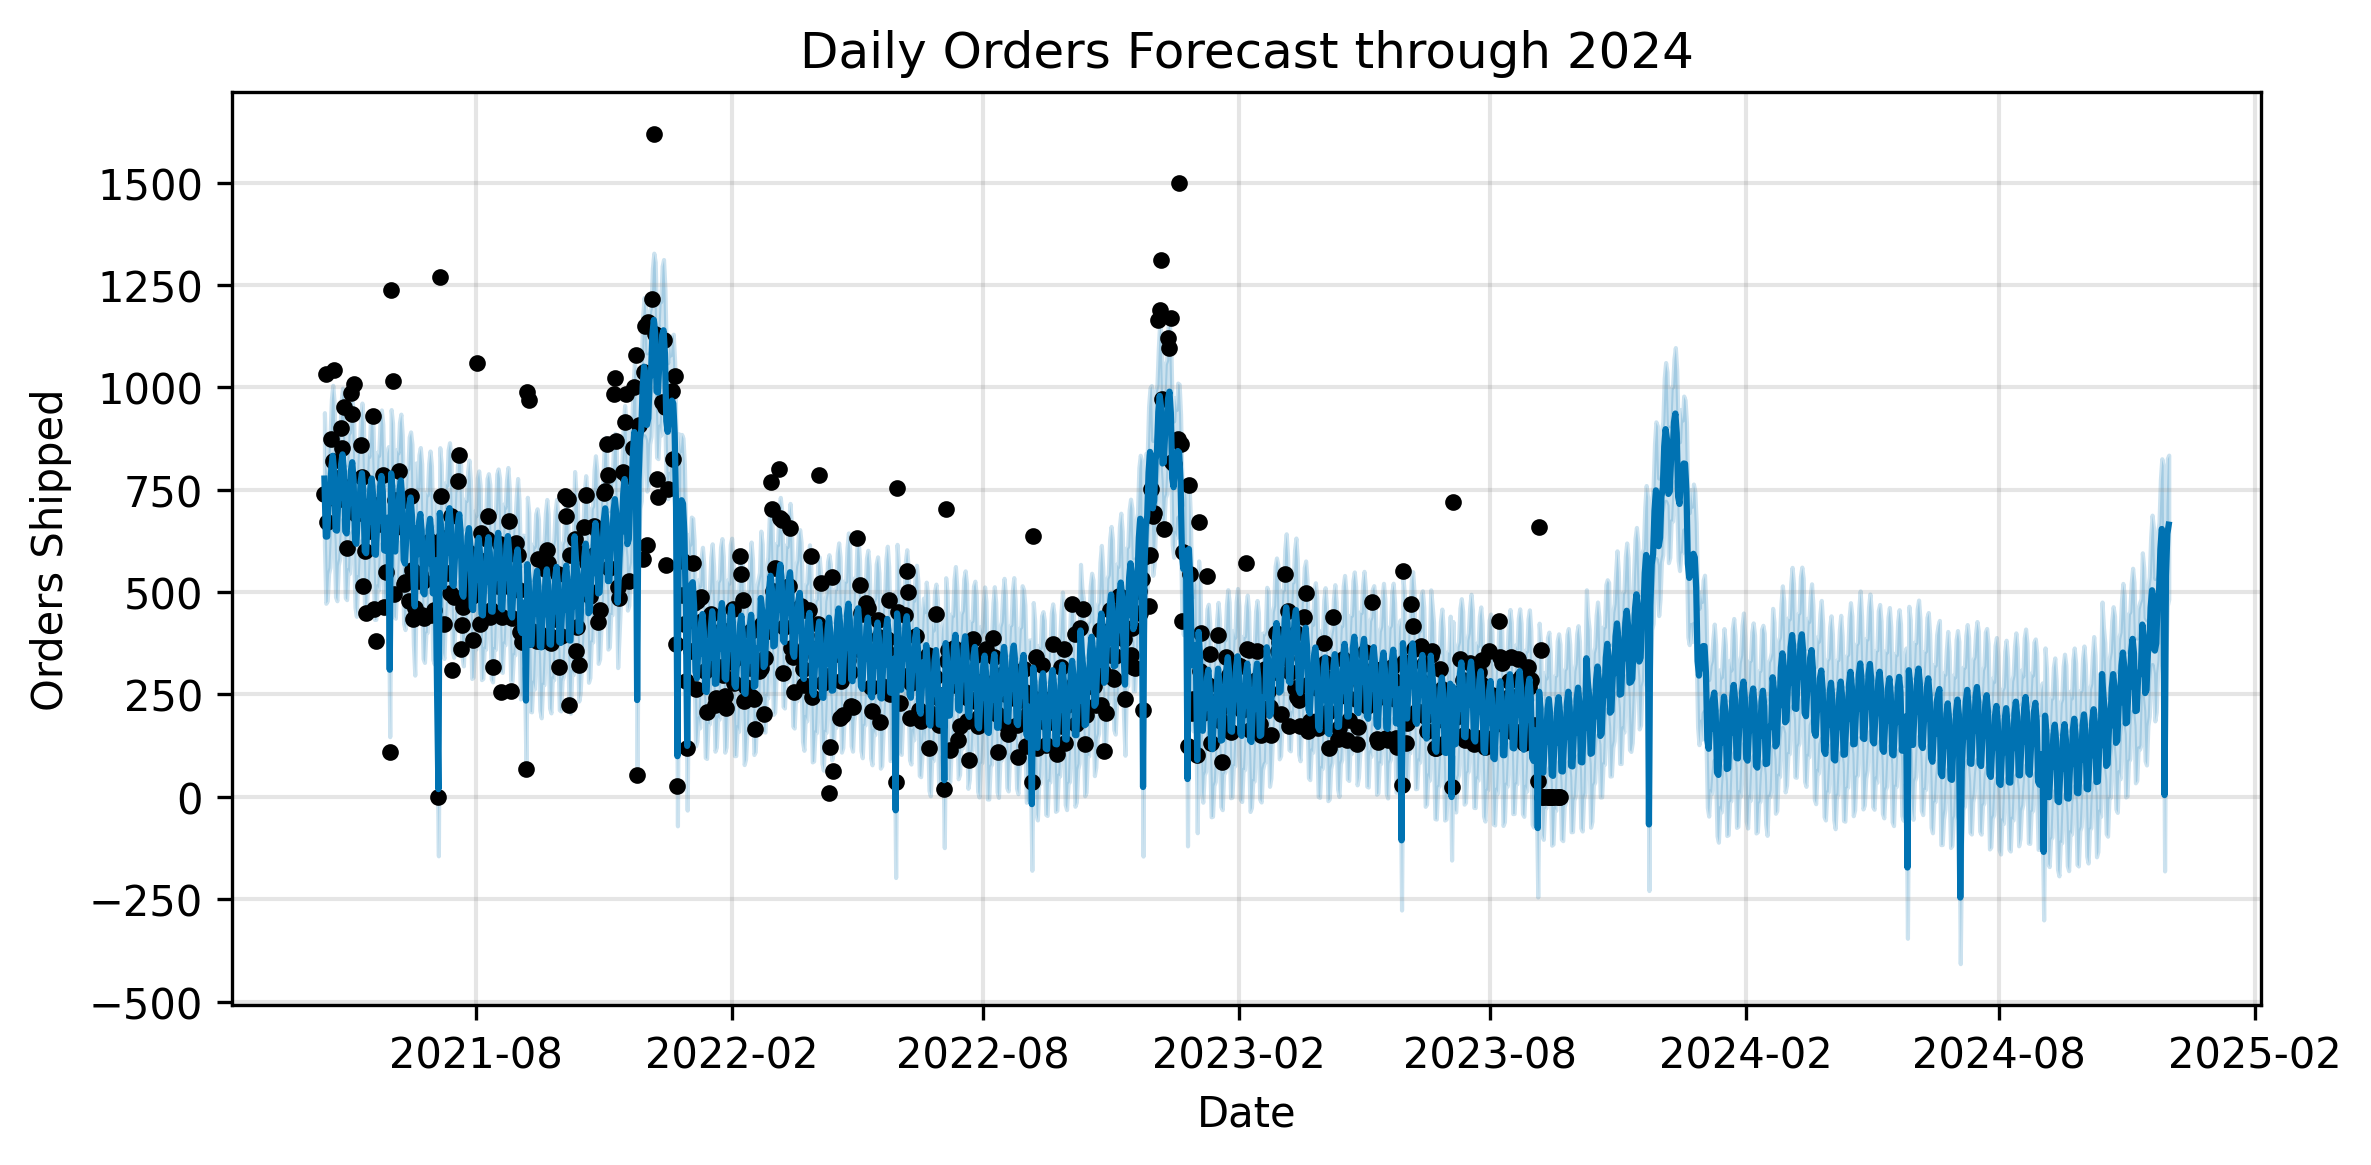

In [6]:
display(Image(filename=PLOT_DIR / 'daily_forecast.png'))

### Daily Components

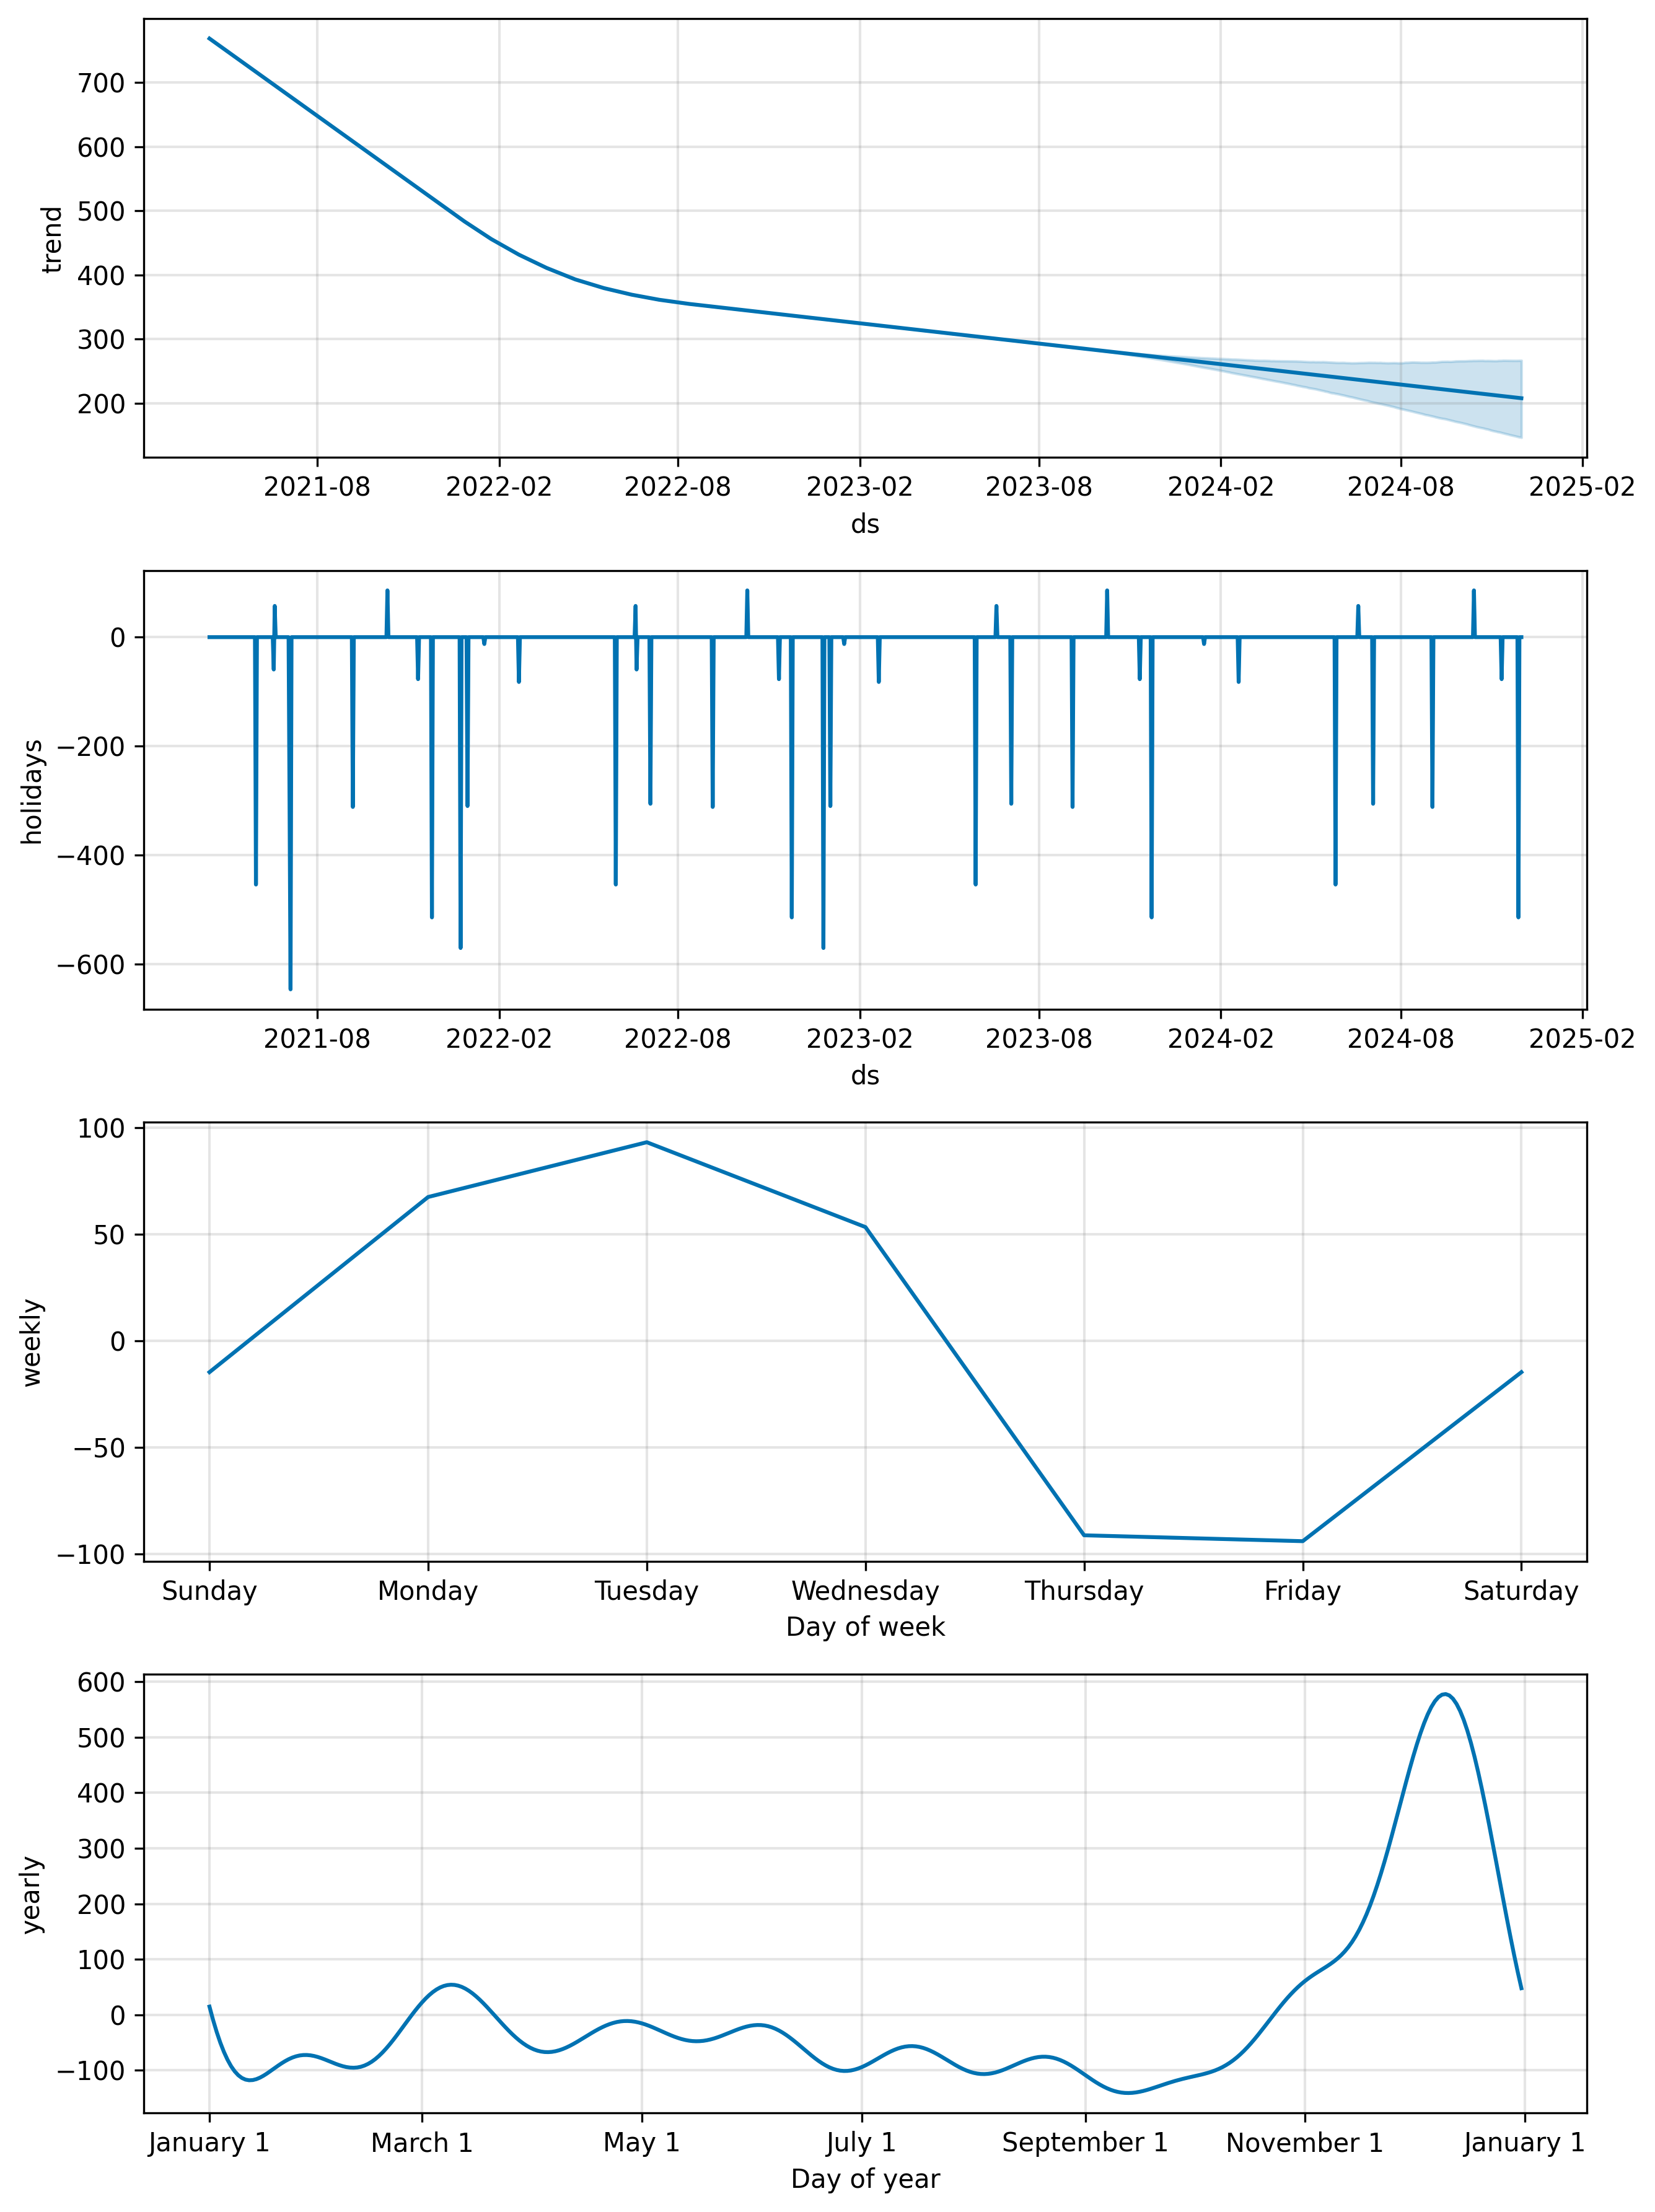

In [7]:
display(Image(filename=PLOT_DIR / 'daily_components.png'))

### Weekly Forecast

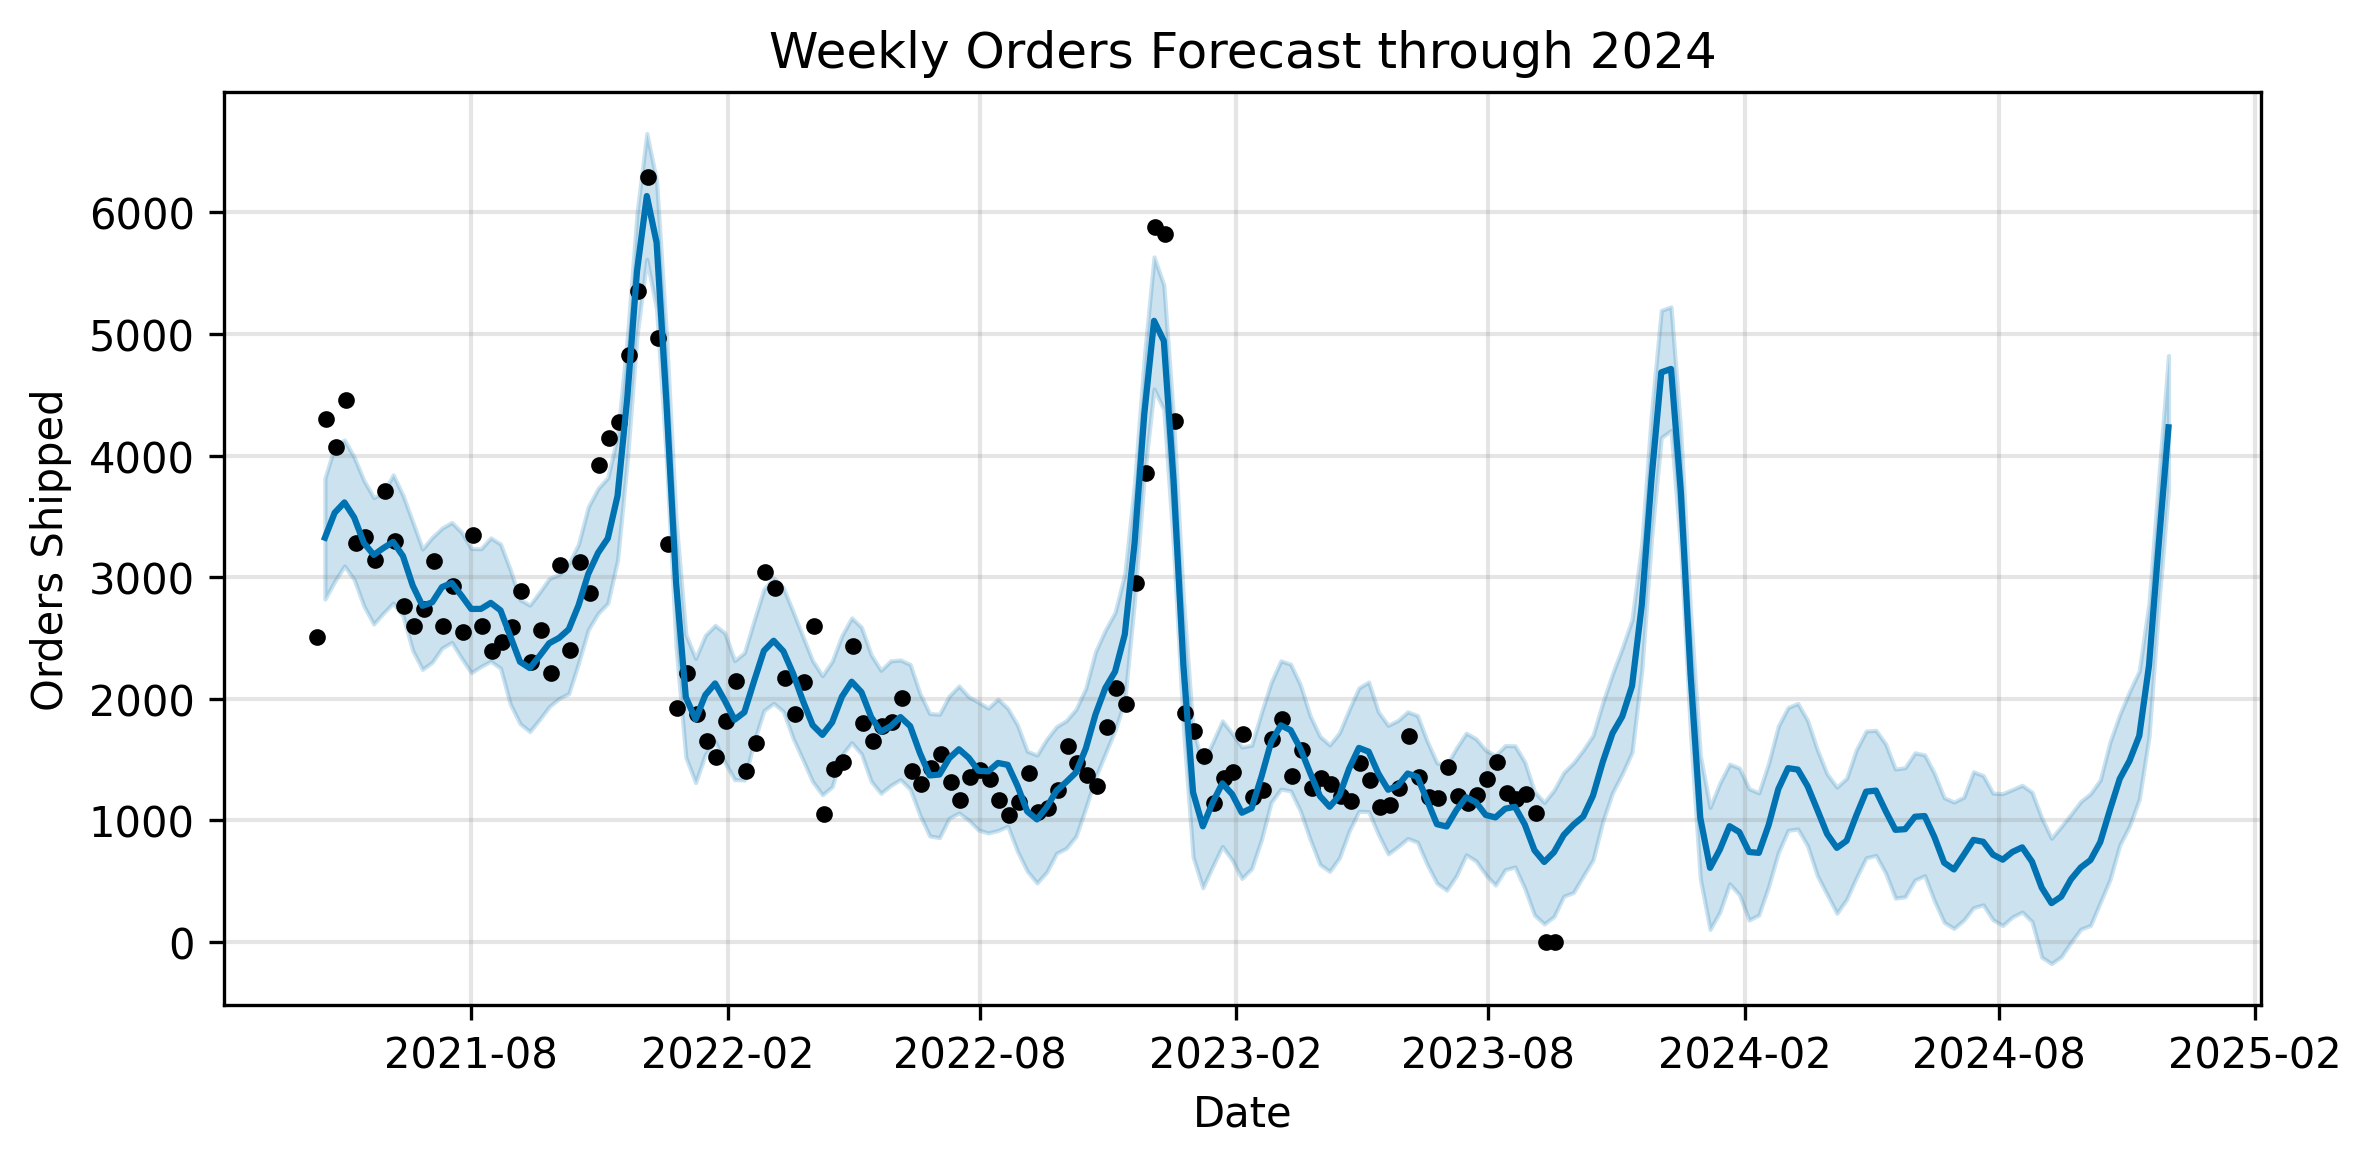

In [8]:
display(Image(filename=PLOT_DIR / 'weekly_forecast.png'))

### Monthly Forecast

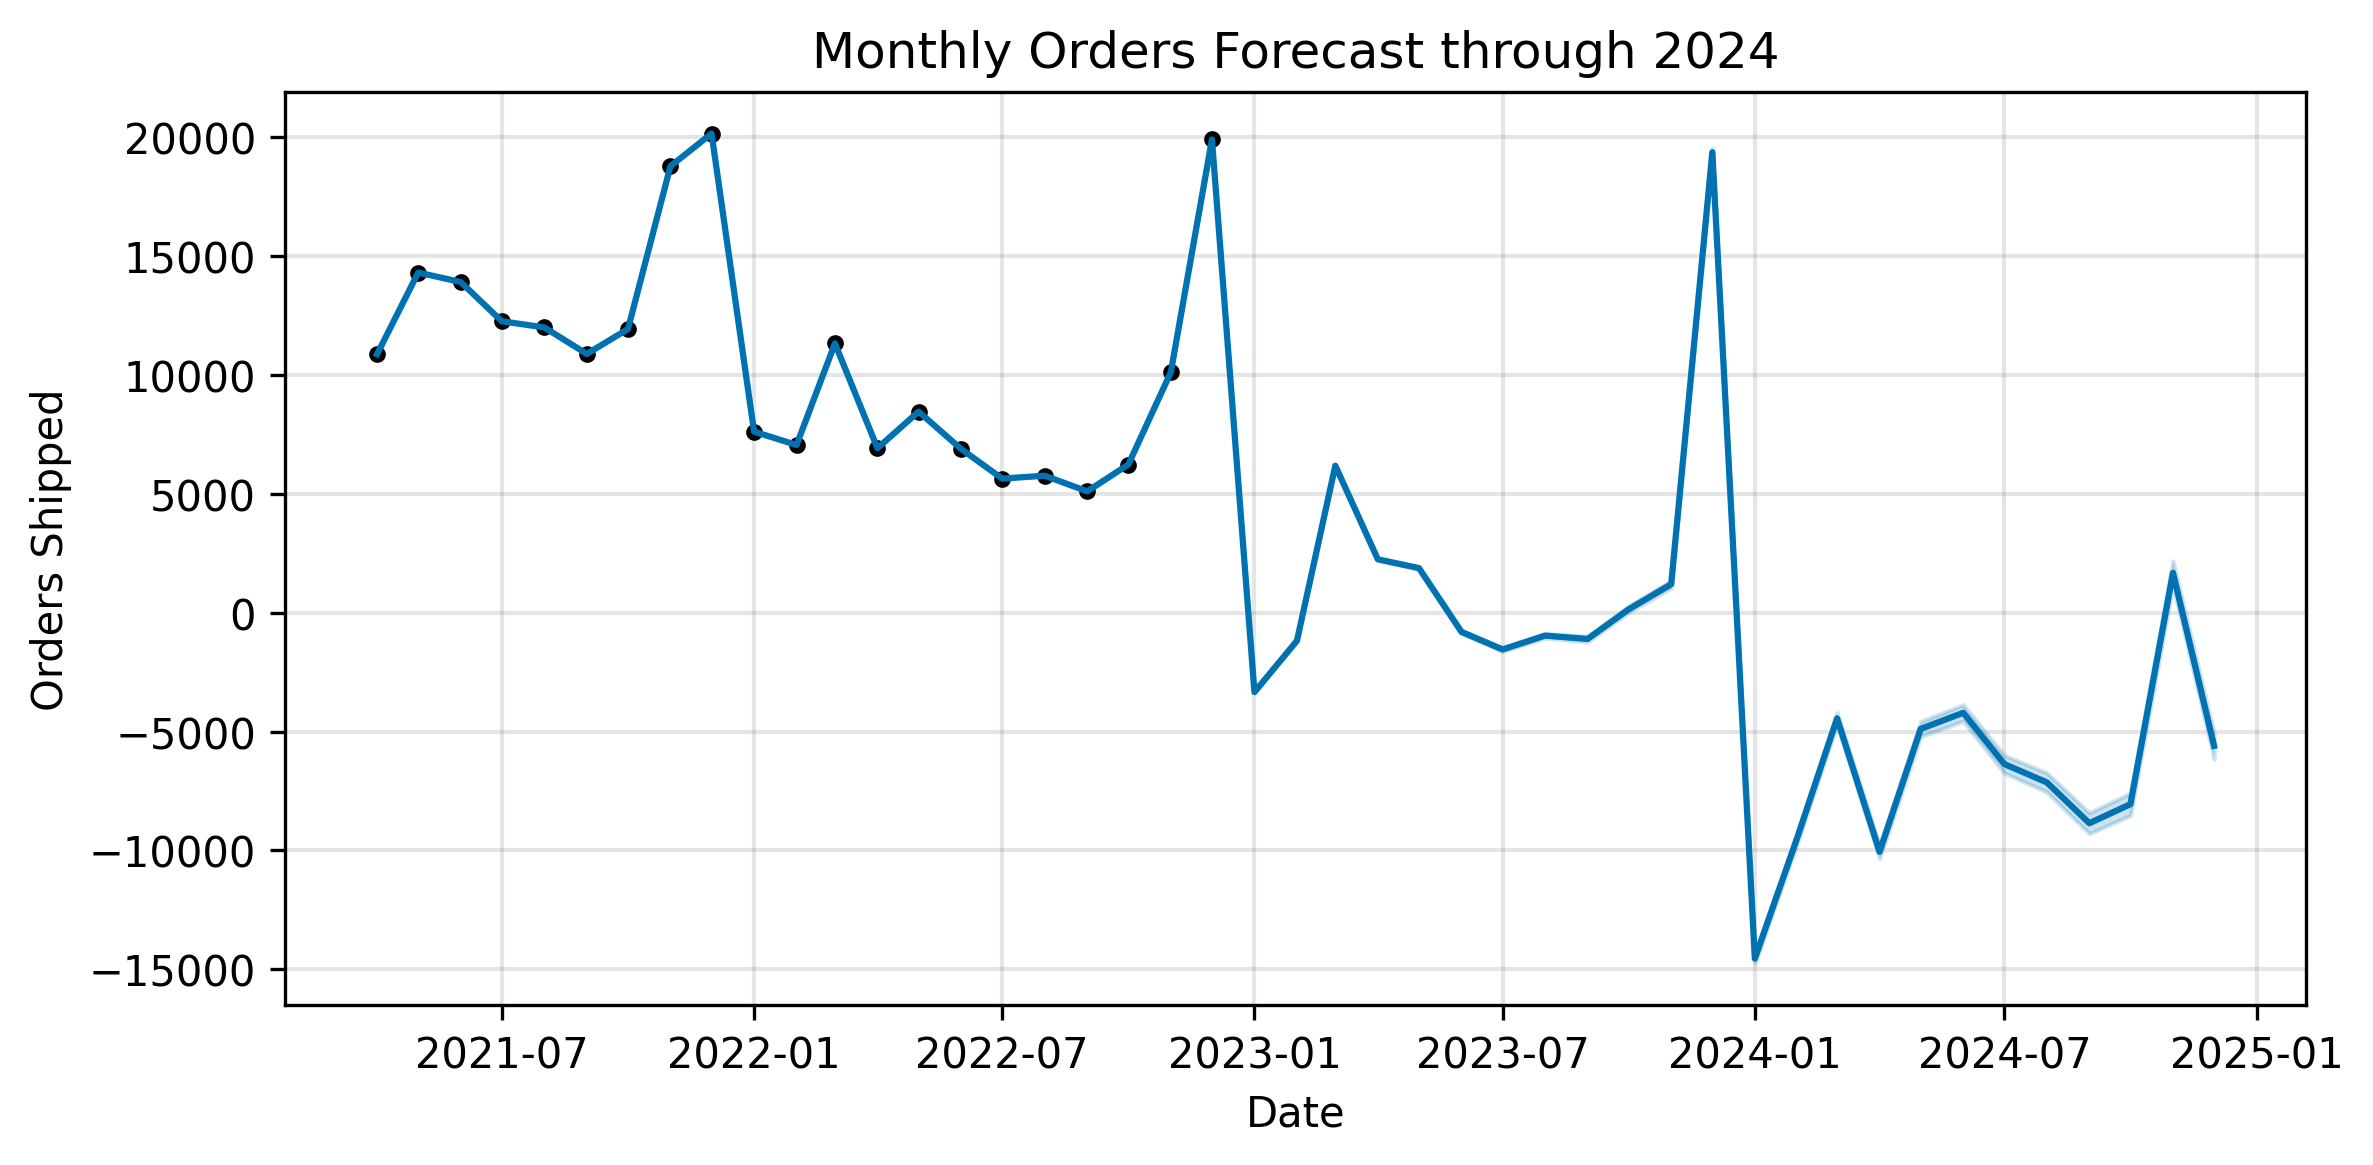

In [9]:
display(Image(filename=PLOT_DIR / 'monthly_forecast.png'))

### Monthly Order Forecast

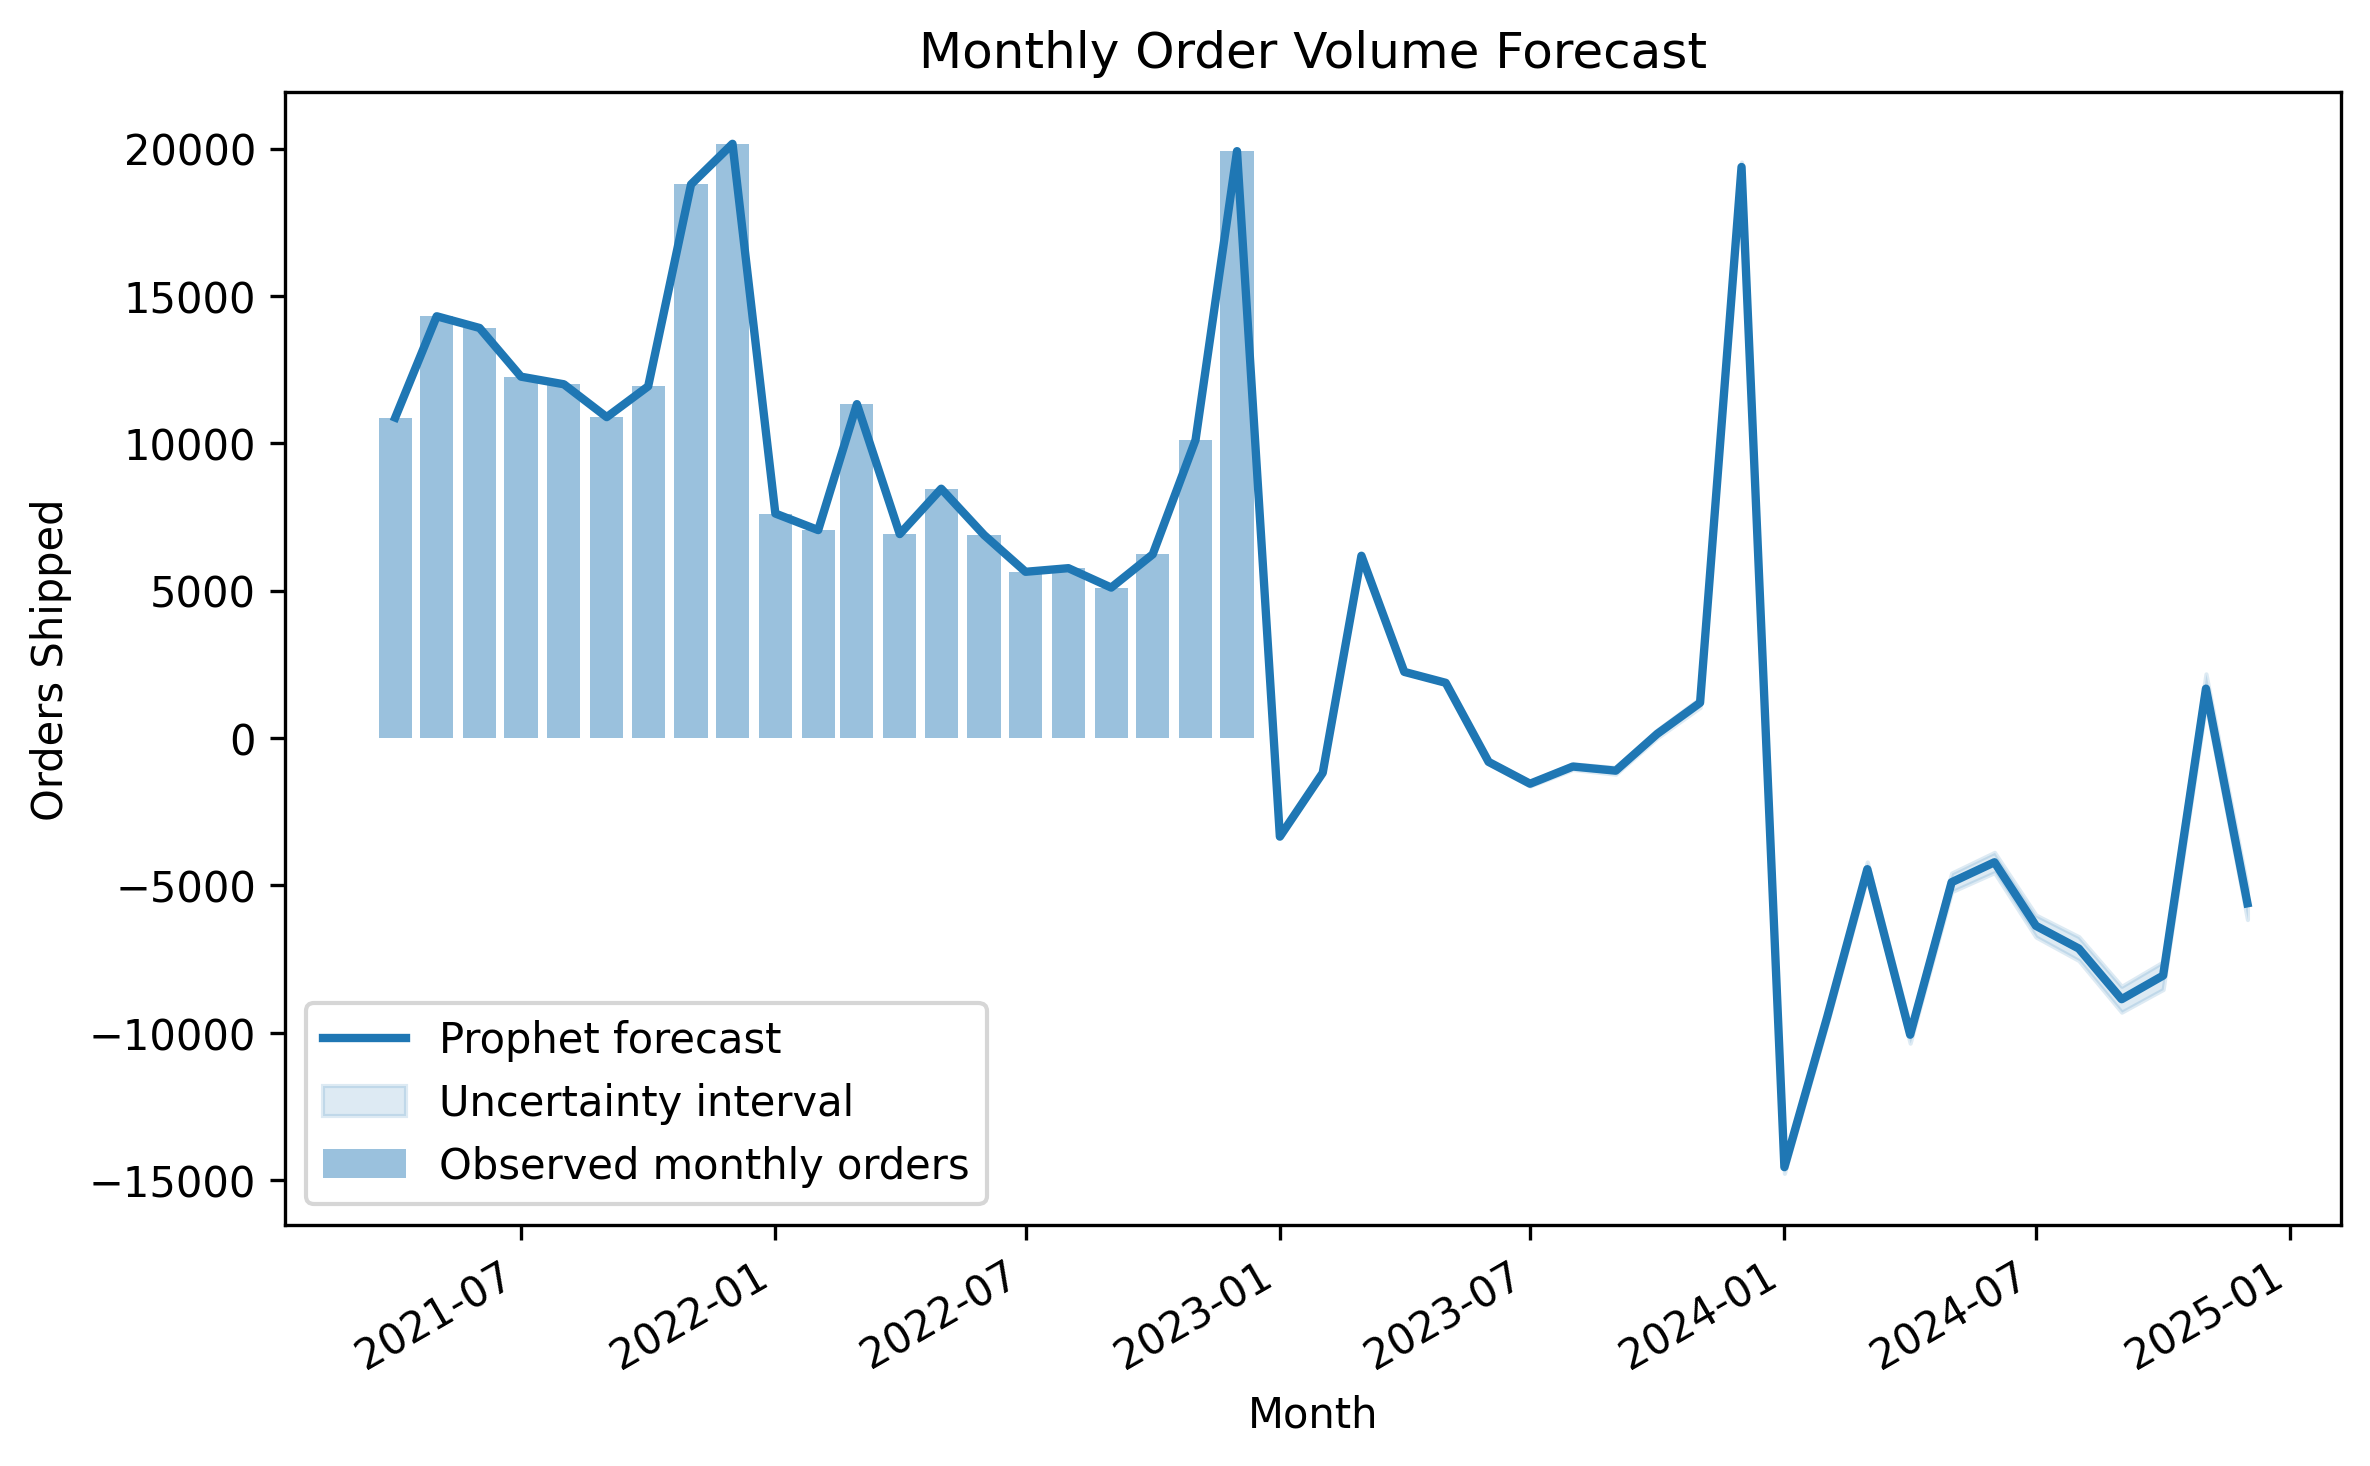

In [10]:
display(Image(filename=PLOT_DIR / 'monthly_order_forecast.png'))

### Prophet Components

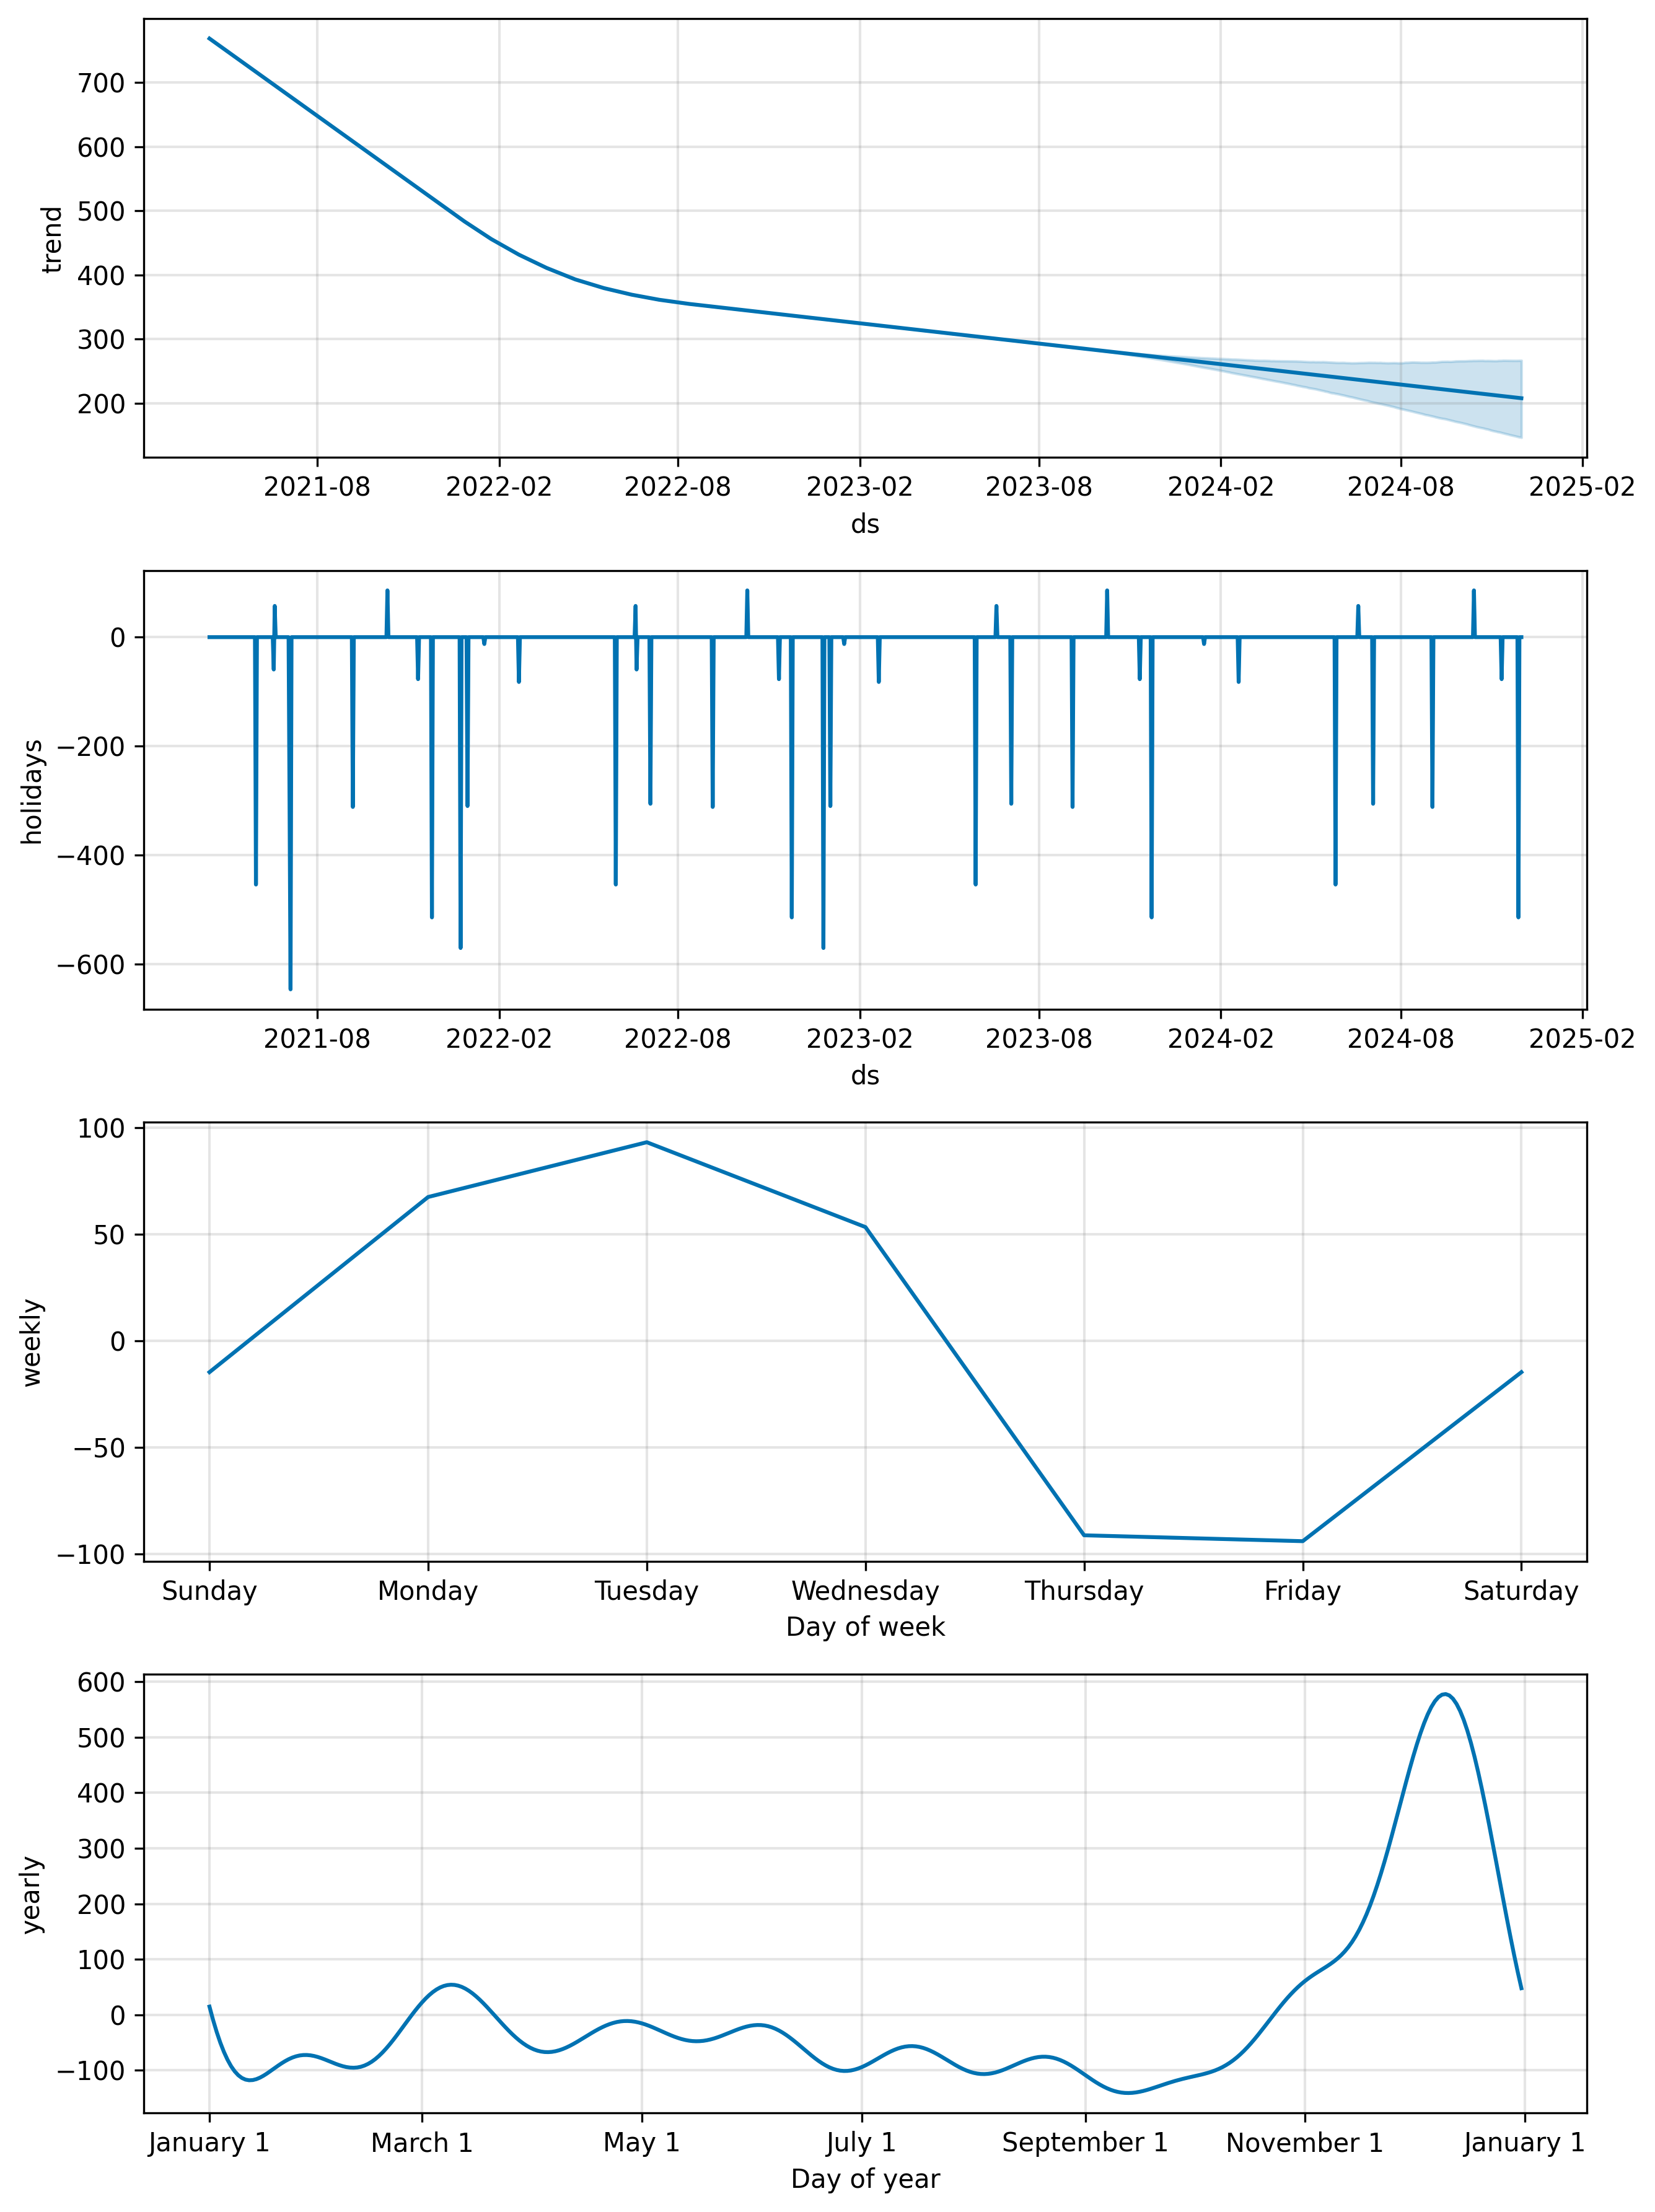

In [11]:
display(Image(filename=PLOT_DIR / 'prophet_all_components.png'))

### Holiday Seasonality Year Over Year

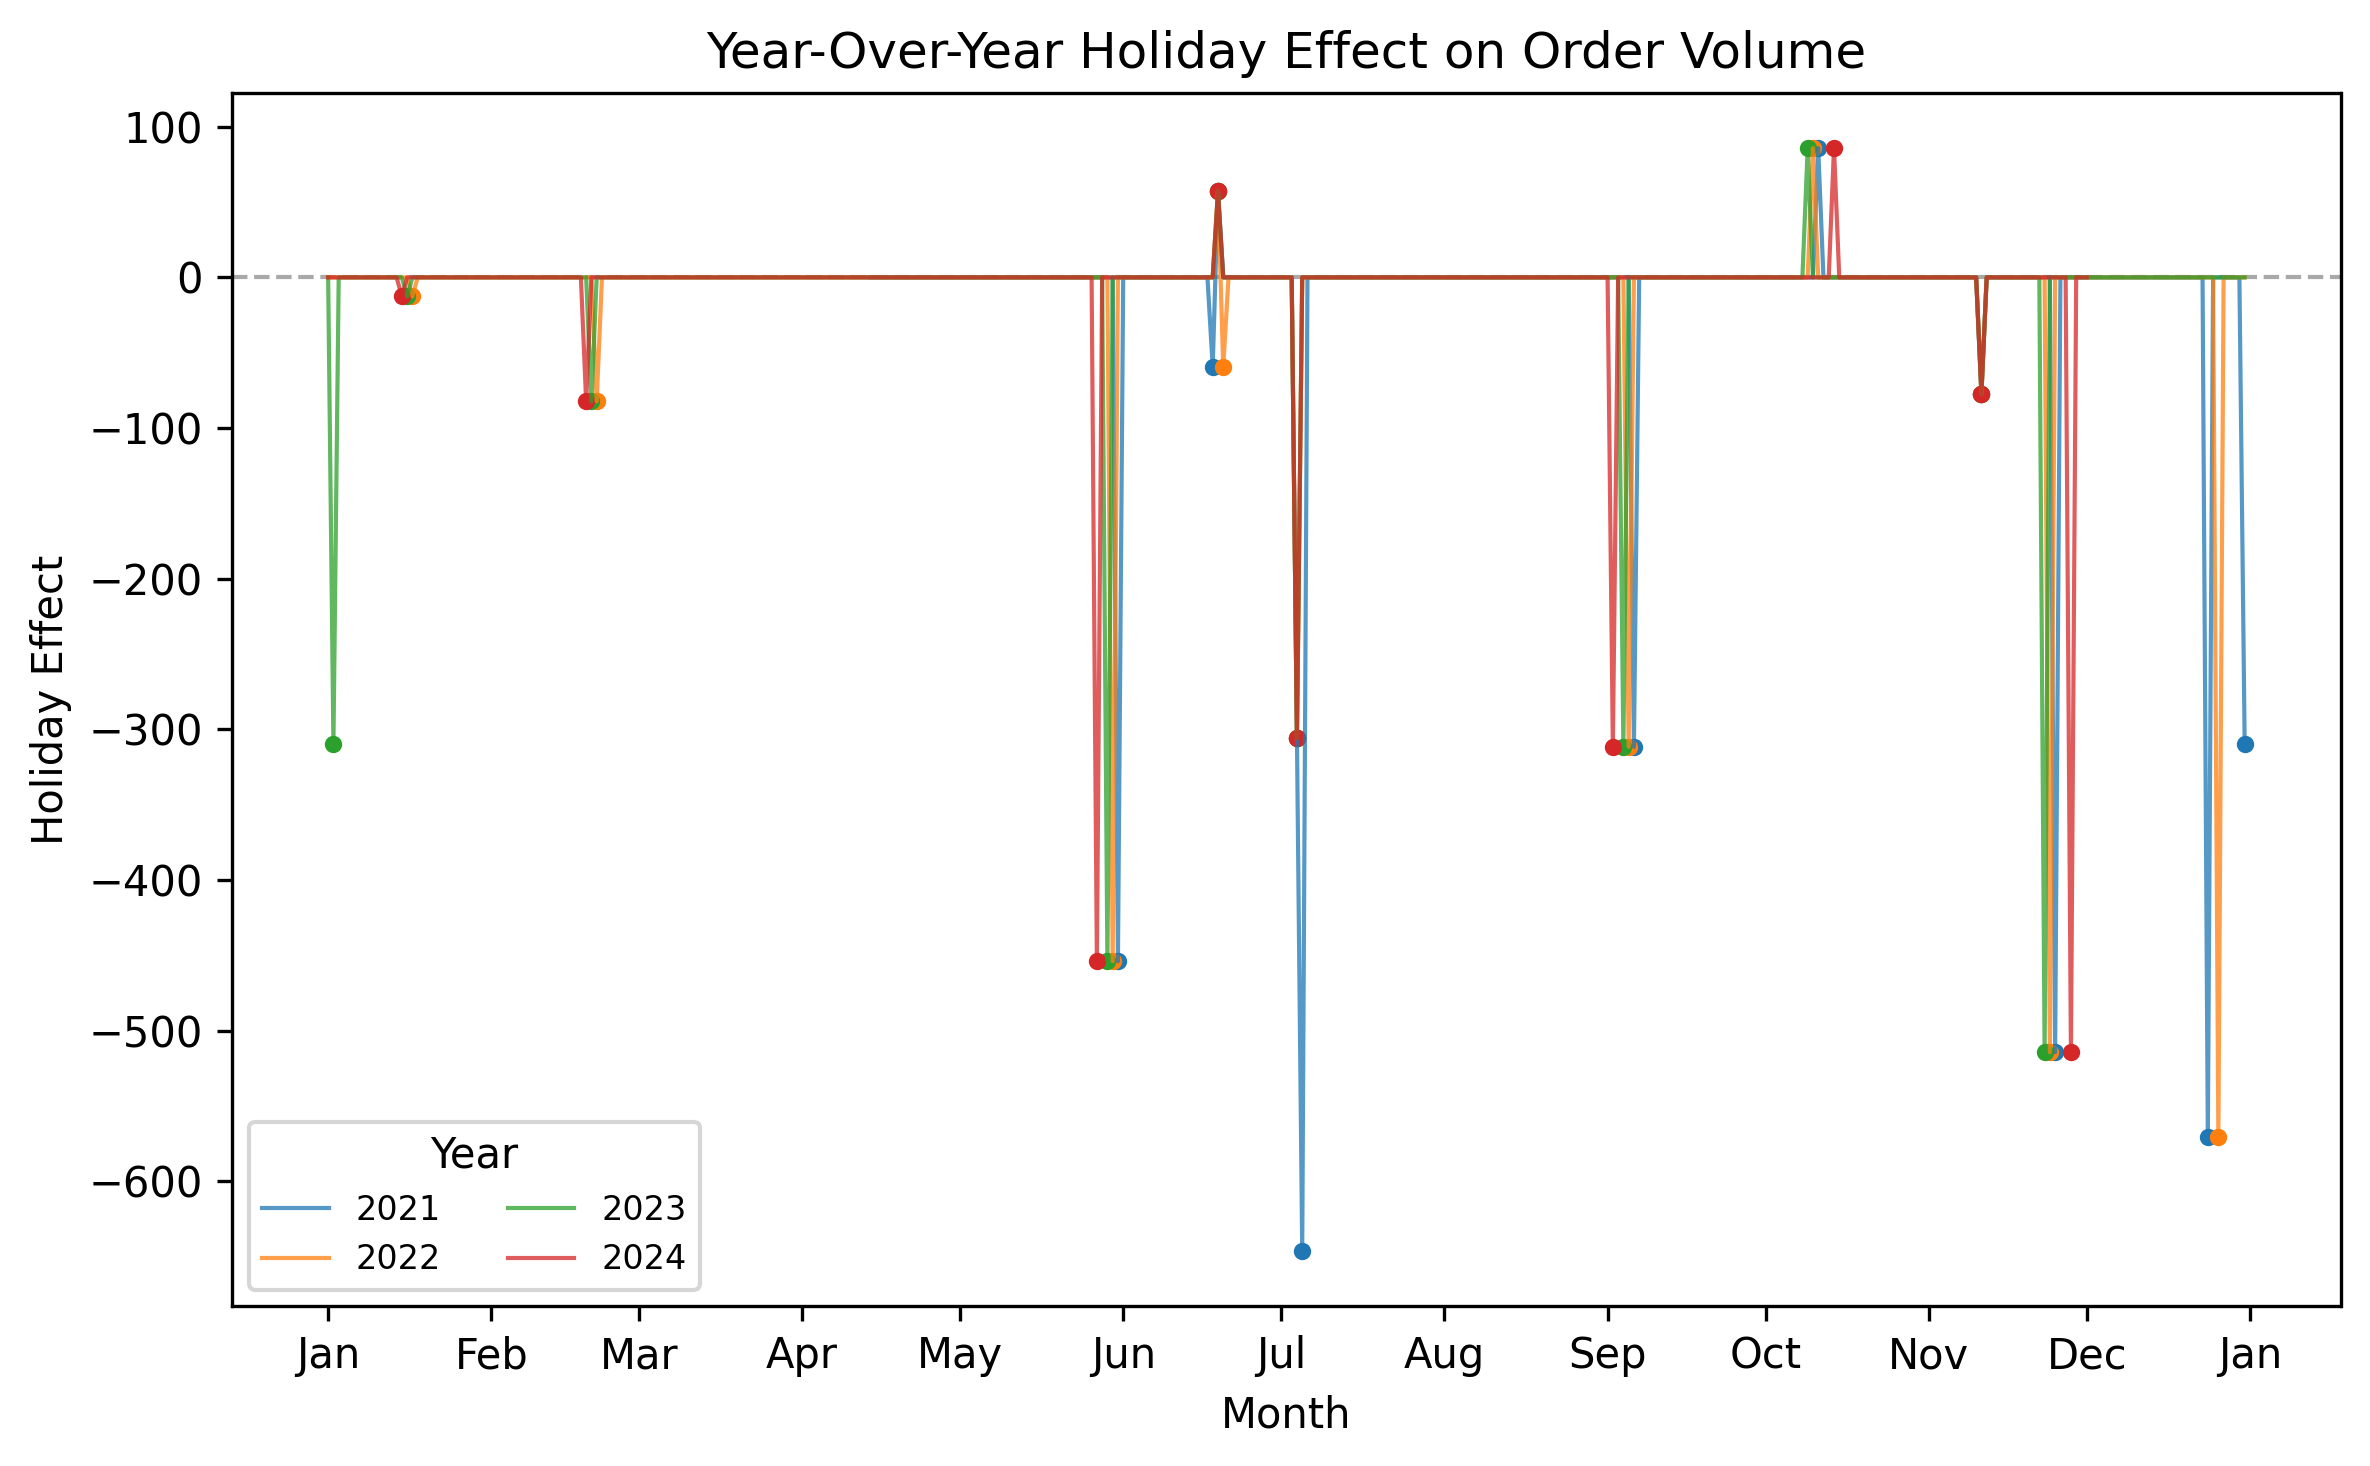

In [12]:
display(Image(filename=PLOT_DIR / 'holiday_seasonality_yoy.png'))

## Output Files

In [13]:
plot_files = sorted(PLOT_DIR.glob('*.png'))
for path in plot_files:
    print(path.relative_to(PROJECT_ROOT))

joel/final_presentation/prophet-plots/daily_components.png
joel/final_presentation/prophet-plots/daily_forecast.png
joel/final_presentation/prophet-plots/holiday_seasonality_yoy.png
joel/final_presentation/prophet-plots/monthly_forecast.png
joel/final_presentation/prophet-plots/monthly_order_forecast.png
joel/final_presentation/prophet-plots/prophet_all_components.png
joel/final_presentation/prophet-plots/weekly_forecast.png
